# M5 Forecast — прогноз спроса как продукт

**Данные:** [M5 Forecasting Accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy) — дневные продажи Walmart, 3049 товаров × 10 магазинов в 3 штатах.

---

### Постановка задачи

| | |
|---|---|
| **Что прогнозируем** | дневные продажи в штуках по паре (товар, магазин), горизонт 28 дней |
| **Кто потребитель** | отдел закупок: нужен батч-прогноз раз в неделю под цикл заказа, а не realtime API |
| **Метрика бизнеса** | WMAPE — «мы ошибаемся на N% объёма». MAPE неприменим: ~68% значений нулевые |
| **Baseline** | seasonal naive (продажи = 28 дней назад) и среднее по дню недели |

**Тезис защиты:** ценность проекта не в скоре, а в том, что вокруг модели есть работающий пайплайн — воспроизводимый, проверяемый и защищённый от главной ошибки прогнозирования рядов.

In [1]:
import json
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from m5.config import load_config
from m5.data.duck import connect

logging.getLogger().setLevel(logging.WARNING)  # в презентации логи не нужны
pd.set_option("display.width", 160)
cfg = load_config()


def q(sql: str) -> pd.DataFrame:
    """Запрос к витрине. read_only: ноутбук ничего не меняет и не блокирует файл."""
    with connect(cfg.paths.duckdb_path, read_only=True) as con:
        return con.execute(sql).df()


print(f"Горизонт прогноза: {cfg.project.horizon} дней")
print(f"Хранилище: {cfg.paths.duckdb_path}")

Горизонт прогноза: 28 дней
Хранилище: /Users/bexultanb/Desktop/fin3/data/m5.duckdb


## 1. Архитектура: слои как в DWH

```
Kaggle CSV → Parquet → DuckDB ─┬─ stg   разворот wide→long, календарь, цены
                               ├─ ft    лаги, окна, витрина фич
                               └─ mart  прогнозы и фактическое качество
                                          ↓
                        LightGBM (tweedie) → MLflow Registry → Airflow
```

**Ключевое решение: feature engineering на SQL, Python — только клей.**
После разворота в длинный формат это ~59 млн строк. `pandas.melt` такое не тянет на ноутбуке в принципе; DuckDB делает `UNPIVOT` и оконные функции out-of-core. Заодно это ближе к тому, как фичи считаются в настоящем DWH.

In [2]:
with connect(cfg.paths.duckdb_path, read_only=True) as con:
    meta = con.execute("""
        SELECT schema_name AS слой, table_name AS таблица
        FROM duckdb_tables() ORDER BY 1, 2
    """).df()
    # точный COUNT(*), а не estimated_size из duckdb_tables(): оценка бывает
    # устаревшей и в презентации расходится с реальными числами
    meta["строк"] = [
        con.execute(f'SELECT COUNT(*) FROM "{r.слой}"."{r.таблица}"').fetchone()[0]
        for r in meta.itertuples()
    ]

meta

,слой,таблица,строк
0,ft,holidays,0
1,ft,lags,640927
2,ft,mart,640927
3,ft,rolling,640927
4,ft,rolling_agg,36840
5,ft,weather,0
6,mart,forecast,16800
7,mart,forecast_accuracy,0
8,stg,calendar,1228
9,stg,calendar_events,1228


## 2. Что было сложного в данных

Данные приходят в **широком** формате: одна строка = ряд, а дни — это колонки `d_1 … d_1941`. Модели нужен длинный формат.

Плюс две ловушки, которые видно только если в данные всмотреться:

1. **Нули до первой продажи** — это не нулевой спрос, а отсутствие товара в ассортименте. Учиться на них значит учить модель, что товар не продаётся.
2. **Календарь длиннее продаж на 28 дней** — в M5 это сделано специально: будущие дни известны (день недели, праздники, SNAP, цены), а факта по ним нет. На этом и строится инференс.

In [3]:
print("Разворот wide → long и обрезка «мусорных» нулей:\n")
print(q("""
    SELECT 'stg.sales_long (после UNPIVOT)' AS этап, COUNT(*) AS строк FROM stg.sales_long
    UNION ALL
    SELECT 'ft.mart (витрина модели)', COUNT(*) FROM ft.mart
    UNION ALL
    SELECT '  из них без факта = будущее', COUNT(*) FROM ft.mart WHERE sales IS NULL
""").to_string(index=False))

Разворот wide → long и обрезка «мусорных» нулей:

                          этап  строк
stg.sales_long (после UNPIVOT) 720000
      ft.mart (витрина модели) 640927
    из них без факта = будущее  16800


## 3. Главная ошибка прогнозирования — утечка через лаги

Ошибка №1 в прогнозировании временных рядов, и она **молчаливая**: ничего не падает, скор на валидации великолепный, а в проде мусор.

**Суть.** Горизонт — 28 дней. Значит в момент прогноза продажи за последние 28 дней ещё не существуют. Фича `lag_7` физически непосчитаема в проде, но на исторических данных она есть, и модель на неё обопрётся.

**Правило проекта:** минимальный лаг ≥ горизонта. Лаги 28/35/42/56/364, скользящие окна сдвинуты на 28 дней.

Ниже — не рассуждение, а проверка на реальных данных.

In [4]:
check = q("""
    SELECT
        COUNT(*) AS проверено_строк,
        SUM(CASE WHEN m.sales_lag_28 = s.sales THEN 1 ELSE 0 END) AS lag28_совпал,
        SUM(CASE WHEN abs(m.roll_mean_7 - w.ручное) < 1e-9 THEN 1 ELSE 0 END) AS окно7_совпало
    FROM ft.mart m
    JOIN stg.sales_enriched s ON s.id = m.id AND s.date = m.date - 28
    JOIN LATERAL (
        SELECT AVG(x.sales) AS ручное FROM stg.sales_enriched x
        WHERE x.id = m.id AND x.date BETWEEN m.date - 34 AND m.date - 28
    ) w ON TRUE
    WHERE m.sales_lag_28 IS NOT NULL AND m.roll_mean_7 IS NOT NULL
""")
print("lag_28 обязан равняться продажам ровно 28 дней назад,")
print("roll_mean_7 — среднему за окно [T-34, T-28], а не за последнюю неделю:\n")
print(check.to_string(index=False))

lag_28 обязан равняться продажам ровно 28 дней назад,
roll_mean_7 — среднему за окно [T-34, T-28], а не за последнюю неделю:

 проверено_строк  lag28_совпал  окно7_совпало
          624127      624127.0       624127.0


### Валидация: rolling origin, никакого random split

```
|------------- train -------------|--- gap 28 ---|--- val 28 ---|
```

4 фолда «лесенкой» назад от последней даты. **Gap в 28 дней обязателен** — без него скользящие статистики на границе захватывают дни из валидации.

На это написаны юнит-тесты (`tests/test_leakage.py`), в том числе проверка «меняем продажи после `as_of` — фичи до `as_of` не изменились».

In [5]:
run = json.loads((Path(cfg.paths.processed_dir) / "models/latest/run.json").read_text())

print(f"Обучение:  {run['train_start']} … {run['train_end']}")
print(f"Gap:       {run['train_end']} … {run['val_start']}   ← модель этих дней не видела")
print(f"Валидация: {run['val_start']} … {run['val_end']}")
print(f"\nПрогноз строится из дня {run['forecast_origin']} — это не то же самое, что конец train.")

Обучение:  2014-01-01 … 2017-02-17
Gap:       2017-02-17 … 2017-03-18   ← модель этих дней не видела
Валидация: 2017-03-18 … 2017-04-14

Прогноз строится из дня 2017-03-17 — это не то же самое, что конец train.


## 4. Модель и результат

**LightGBM, objective = `tweedie`.** ~68% таргета — нули. Tweedie это смесь пуассоновского процесса (сколько покупок) и гамма-распределения (размер покупки) — ровно структура прерывистого розничного спроса.

**10 моделей по магазинам** вместо одной: меньше пик памяти, и каждая ловит специфику своего магазина.

Сначала считаем baseline — без него непонятно, хороший скор или стыдный.

In [6]:
from m5.models.baseline import run_baselines

baselines = run_baselines(cfg)  # 3 baseline'а × 4 фолда, ~5 секунд
by_baseline = baselines.groupby("baseline")["wmape"].mean()

table = pd.DataFrame(
    {"WMAPE (среднее по 4 фолдам)": [
        by_baseline["seasonal_naive"],
        by_baseline["moving_average"],
        by_baseline["dow_mean"],
        run["metrics"]["wmape"],
    ]},
    index=["baseline: seasonal naive", "baseline: скользящее среднее",
           "baseline: среднее по дню недели", "→ LightGBM tweedie"],
).round(4)

gain = (1 - run["metrics"]["wmape"] / by_baseline.min()) * 100
print(table.to_string())
print(f"\nМодель лучше сильнейшего baseline на {gain:.1f}%")

                                 WMAPE (среднее по 4 фолдам)
baseline: seasonal naive                              0.7185
baseline: скользящее среднее                          0.5539
baseline: среднее по дню недели                       0.5609
→ LightGBM tweedie                                    0.4849

Модель лучше сильнейшего baseline на 12.5%


Бэктест по всем 4 фолдам: **WMAPE 0.508 ± 0.019**, модель бьёт baseline на каждом фолде (выигрыш 8.4–10.8%).

Разброс важнее среднего: если бы скор скакал от 0.45 до 0.62, одно число вводило бы в заблуждение.

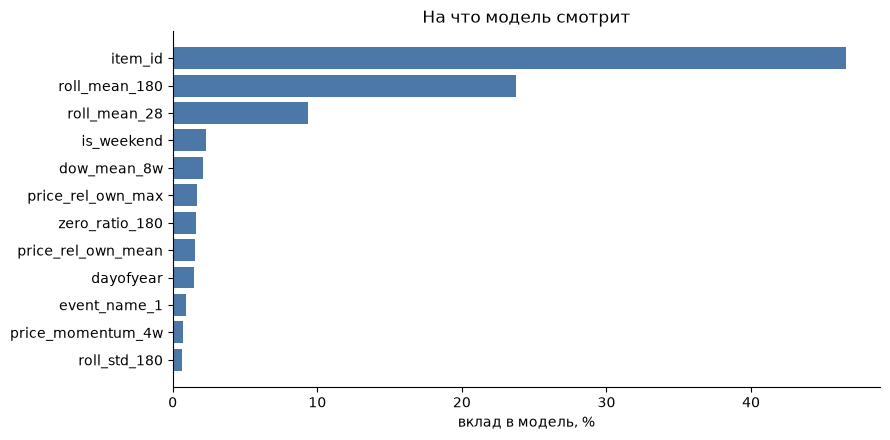

In [7]:
imp = pd.read_csv(Path(cfg.paths.processed_dir) / "models/latest/feature_importance.csv").head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(imp["feature"][::-1], imp["gain_share"][::-1] * 100, color="#4C78A8")
ax.set_xlabel("вклад в модель, %")
ax.set_title("На что модель смотрит")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Список читается осмысленно: уровень товара, базовый уровень ряда за полгода, недавний уровень, недельная сезонность, прерывистость спроса, реакция на цену, праздники. Ничего случайного в топе нет.

## 5. Прогноз доезжает до витрины

**Самое важное архитектурное требование выполнено: фичи для обучения и для инференса считает один и тот же SQL.**

Staging строит полную сетку (ряд × день) по календарю, а календарь длиннее продаж на горизонт. Будущие 28 дней лежат в той же таблице со всеми известными атрибутами и `sales = NULL`. Лаги для них берут историю — той же оконной функцией.

Отдельного «скрипта для прода» нет, а значит неоткуда взяться training/serving skew — классическому прод-багу, когда на валидации всё прекрасно, а в проде мусор.

 прогнозов  рядов          с         по версия_модели
     16800    600 2017-04-15 2017-05-12   registry:v1


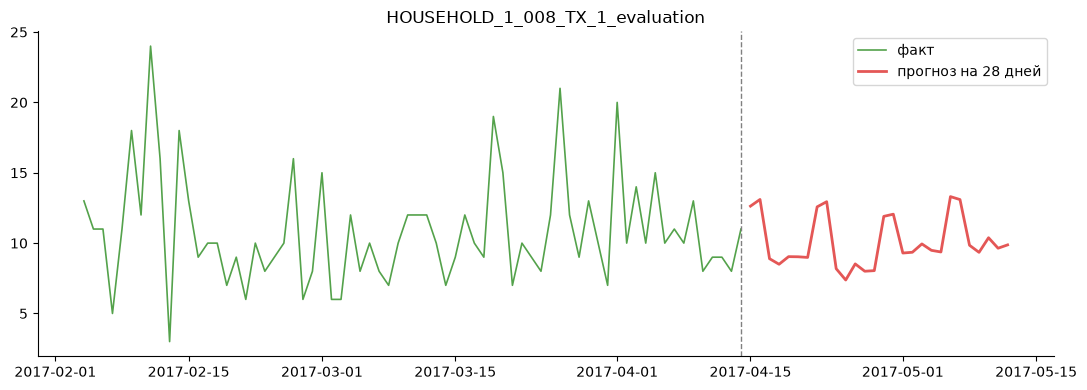

In [8]:
print(q("""
    SELECT COUNT(*) AS прогнозов, COUNT(DISTINCT id) AS рядов,
           MIN(date) AS с, MAX(date) AS по, ANY_VALUE(model_version) AS версия_модели
    FROM mart.forecast
""").to_string(index=False))

series = q("SELECT id FROM mart.forecast GROUP BY id ORDER BY SUM(prediction) DESC LIMIT 1")["id"][0]
hist = q(f"""
    SELECT date, sales FROM stg.sales_enriched
    WHERE id = '{series}' AND sales IS NOT NULL
    ORDER BY date DESC LIMIT 70
""").sort_values("date")
fc = q(f"SELECT date, prediction FROM mart.forecast WHERE id = '{series}' ORDER BY date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["date"], hist["sales"], color="#54A24B", lw=1.2, label="факт")
ax.plot(fc["date"], fc["prediction"], color="#E45756", lw=2, label="прогноз на 28 дней")
ax.axvline(hist["date"].max(), color="grey", ls="--", lw=1)
ax.set_title(f"{series}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Перед записью в витрину прогноз проходит **6 sanity-checks**: нет NaN и отрицательных, нет дублей, присутствуют все 28 горизонтов, число строк = ряды × горизонт, объём в пределах ±40% от факта за прошлые 28 дней.

При провале любой — запись не происходит (*fail closed*). Плохой прогноз хуже отсутствия прогноза: по нему закупят товар.

## 6. Оркестрация: Airflow + MLflow

**DAG `m5_training`**, еженедельно, отрабатывает за 2.5 минуты:

```
ingest → validate → external → build_features → train → backtest
       → is_better_than_production → register_model
```

`validate` — жёсткий гейт с `retries=0`: проверяет 6 SQL-инвариантов (дубли, отрицательные продажи, дыры в календаре, продажи без цены) и **роняет пайплайн**. Ретраить битые данные бессмысленно, сами они не починятся.

### Гейт промоушена — то, ради чего всё

Последний прогон в проде:

> `кандидат v2 wmape=0.4849, прод v1 wmape=0.4860, порог 0.4812 (min_improvement=1%) — недостаточно лучше, прод остаётся`

Новая модель **объективно лучше**, но выигрыш меньше 1%. Гейт отказался её промоутить: такая разница — разброс между фолдами, а не прогресс. Прод не должен дёргаться на шуме каждую неделю.

Таск помечается `skipped`, а не `failed` — «модель не стала лучше» это штатный исход недели, а не авария.

## 7. Что было улучшено по ходу работы

Не «сделал по плану», а нашёл и исправил:

| Проблема | Как проявлялась | Решение |
|---|---|---|
| `as_of` из Airflow уходил в будущее | обучение **без валидации и early stopping**, метрик нет, статус зелёный | обрезка до последней даты с фактом + `EmptyValidationError` |
| Группы горизонтов в конфиге бессмысленны | 4 модели обучались бы на идентичных данных | разобрался и задокументировал, вместо того чтобы тащить «по плану» |
| PythonOperator падал молча | `return code 1`, traceback отсутствует | `fork()` многопоточного воркера + импорт OpenMP; переделал на вызов CLI |
| DAG шёл 3 часа | ретраи по 5→10→20 мин на необязательном шаге | `retries=0` там, где ретрай бесполезен |
| MLflow отдавал 403 из контейнера | защита от DNS rebinding в MLflow 3.x | явный список разрешённых хостов, без отключения защиты |

Отдельно: добавлен генератор синтетических данных той же формы — пайплайн прогоняется целиком без Kaggle-аккаунта, что делает возможным CI и онбординг.

## 8. Честный статус

**Работает:** слой данных, валидация, витрина фич, rolling-origin CV, модель бьёт baseline, инференс в витрину, MLflow Registry с гейтом, Airflow по расписанию, всё в Docker, тесты и CI.

**Не сделано:** WRMSSE (метрика соревнования), внешние данные (погода Open-Meteo и праздники Nager.Date — заготовлены, но нужен ablation, чтобы доказать пользу), мониторинг дрифта, FastAPI и дашборд.

Закрыто 6 шагов роадмапа из 11, ещё 4 частично.

---

**Главный вывод, который я вынес:** самое ценное в проекте — не модель, а проверки вокруг неё. Тест на утечку, гейт промоушена и sanity-checks поймали больше реальных проблем, чем любой тюнинг гиперпараметров.